- 线性回归的从零开始实现
    - 数据流水线
    - 模型构建
    - 损失函数
    - 优化算法

In [1]:
#导入必要的库
%matplotlib inline  
import torch
import random
from d2l import torch as d2l

- 生成数据集
根据带有噪声的线性模型构造一个人造数据集。我们使用线性模型参数
$\mathbf{w} = [2, -3.4]^\top$、$b = 4.2$ 和噪声项 $\epsilon$ 生成数据集及其标签：

$$
\mathbf{y} = \mathbf{X}\mathbf{w} + b + \epsilon
$$

In [2]:
def synthetic_data(W,b,num_examples):
    '''
    param W:权重
          b:偏差
          num_examples:样本数量
    生成y=Xw+b+噪声
    '''
    x = torch.normal(0,1,(num_examples,len(W)))
    y = torch.matmul(x,W)+b
    y += torch.normal(0,0.01,y.shape)  #添加随机噪音
    return x,y.reshape((-1,1))
true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([-0.9582,  0.9337]) 
label: tensor([-0.9004])


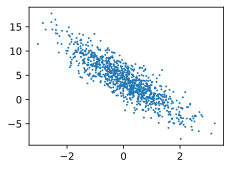

In [3]:
#可视化
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),
                labels.detach().numpy(),1)
d2l.plt.show()  

- 定义一个data_iter函数，该函数接受批量大小、特征矩阵和标签向量作为输入，并生成一个批量大小的随机小批量。每次迭代时，data_iter函数都会返回一个包含特征和标签的小批量。

In [4]:
def data_iter(batch_size,features,labels):
    '''
    param batch_size:批量大小
          features:特征矩阵
          labels:标签向量
    生成一个大小为batch_size的小批量随机样本
    '''
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)  #打乱顺序
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size,num_examples)]
        ) #这了取min是因为最后一次可能不足一个batch_size
        yield features[batch_indices],labels[batch_indices]
batch_size = 10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[-0.8276, -0.8285],
        [ 0.5376,  0.1092],
        [ 0.6154,  0.9030],
        [ 0.1404, -0.4985],
        [-1.0352,  1.9580],
        [-3.1152,  0.0543],
        [-1.5787, -0.8031],
        [ 0.4214, -0.4217],
        [ 0.6078, -0.1759],
        [-1.1197, -0.3626]]) 
 tensor([[ 5.3538],
        [ 4.9084],
        [ 2.3559],
        [ 6.1873],
        [-4.5159],
        [-2.2312],
        [ 3.7926],
        [ 6.4827],
        [ 6.0201],
        [ 3.2012]])


- 定义初始化模型参数

In [5]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True) #生成一个2行1列的矩阵，元素服从均值为0，标准差为0.01的正态分布
b = torch.zeros(1,requires_grad=True)
#requires_grad=True表示需要计算梯度

- 定义模型

In [6]:
def linreg(X,w,b): 
    '''
    这就是前面的那个函数y=Xw+b
    param X:特征
          w:权重
          b:偏差
    线性回归模型
    '''
    return torch.matmul(X,w)+b

- 定义损失函数

In [7]:
def squared_loss(y_hat,y):
    '''
    param y_hat:预测值
          y:标签 --真实值
    这里返回的是向量,而不是标量
    '''
    return (y_hat-y.reshape(y_hat.shape))**2/2

- 定义优化算法

In [8]:
def sgd(params:list,lr:float,batch_size:int):
    '''
    param params:模型参数
          lr:学习率
          batch_size:批量大小
    小批量随机梯度下降
    '''
    with torch.no_grad(): #不需要计算梯度
        for param in params:
            param -= lr*param.grad/batch_size #更新参数
            param.grad.zero_() #梯度清零 因为pytorch中默认是累加梯度的，不清理会影响我们要的结果

- 训练过程

In [9]:
lr = 0.03 #学习率
num_epochs = 3 #训练周期
net = linreg #线性模型
loss = squared_loss #损失函数
#之所以把net和loss单独拿出来，是为了后面方便替换成其他的模型和损失函数

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y) #计算损失

        # 也可以先清零梯度，后面的sgd就不用清零了，这样子更加符合pytorch的习惯顺序
        # for parm in [w,b]:
        #     parm.grad.zero_() #梯度清零

        l.sum().backward() #反向传播计算梯度
        sgd([w,b],lr,batch_size) #更新参数
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch+1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.039087
epoch 2, loss 0.000146
epoch 3, loss 0.000048


In [10]:
# 比较真实参数和学到的参数
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 0.0013, -0.0001], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0012], grad_fn=<RsubBackward1>)


- 反面例子，学习率不能太大也不能太小

In [11]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True) #生成一个2行1列的矩阵，元素服从均值为0，标准差为0.01的正态分布
b = torch.zeros(1,requires_grad=True)
#requires_grad=True表示需要计算梯度

lr = 0.003 #学习率---------------（太小）
num_epochs = 3 #训练周期
net = linreg #线性模型
loss = squared_loss #损失函数
#之所以把net和loss单独拿出来，是为了后面方便替换成其他的模型和损失函数

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y) #计算损失
        l.sum().backward() #反向传播计算梯度
        sgd([w,b],lr,batch_size) #更新参数
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch+1}, loss {float(train_l.mean()):f}')

epoch 1, loss 9.079111
epoch 2, loss 5.006351
epoch 3, loss 2.761959


In [12]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True) #生成一个2行1列的矩阵，元素服从均值为0，标准差为0.01的正态分布
b = torch.zeros(1,requires_grad=True)
#requires_grad=True表示需要计算梯度

lr = 3 #学习率---------------（太大）
num_epochs = 3 #训练周期
net = linreg #线性模型
loss = squared_loss #损失函数
#之所以把net和loss单独拿出来，是为了后面方便替换成其他的模型和损失函数

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y) #计算损失
        l.sum().backward() #反向传播计算梯度
        sgd([w,b],lr,batch_size) #更新参数
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch+1}, loss {float(train_l.mean()):f}')

epoch 1, loss inf
epoch 2, loss nan
epoch 3, loss nan
